In [ ]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

import random


In [ ]:

CSV_PATH = "hotel_bookings (1).csv"


raw_df = pd.read_csv(CSV_PATH)

print("Shape:", raw_df.shape)
print("Columns:\n", raw_df.columns.tolist())
raw_df.head()




Shape: (119390, 33)
Columns:
 ['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date', 'city']


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,city
0,Resort Hotel - Chandigarh,0,342,2024,July,30,27,0,0,2,...,NaN,NaN,0,Transient,0.0,0,0,Check-Out,12:16:41 AM,Chandigarh
1,Resort Hotel - Mumbai,0,737,2024,April,17,28,0,0,2,...,NaN,NaN,0,Transient,0.0,0,0,Check-Out,12:56:22 AM,Mumbai
2,Resort Hotel - Delhi,0,7,2024,September,37,10,0,1,1,...,NaN,NaN,0,Transient,75.0,0,0,Check-Out,12:46:26 AM,Delhi
3,Resort Hotel - Kolkata,0,13,2024,August,33,14,0,1,1,...,304.0,NaN,0,Transient,75.0,0,0,Check-Out,12:07:10 AM,Kolkata
4,Resort Hotel - Lucknow,0,14,2024,September,37,14,0,2,2,...,240.0,NaN,0,Transient,98.0,0,1,Check-Out,12:27:33 AM,Lucknow


In [ ]:


raw_df.info()

print("\nMissing values per column:\n")
print(raw_df.isna().sum().sort_values(ascending=False))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 33 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:
# Data Cleaning & Preprocessing


df = raw_df.copy()

# Handle missing values


numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

for col in numeric_cols:
    if df[col].isna().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

for col in cat_cols:
    if df[col].isna().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

print("Remaining missing values:")
print(df.isna().sum().sum())




if "reservation_status_date" in df.columns:
    df["reservation_status_date"] = pd.to_datetime(df["reservation_status_date"], errors="coerce")


for col in ["children", "babies"]:
    if col in df.columns:
        df[col] = df[col].astype(float).astype(int)



before = df.shape[0]
df.drop_duplicates(inplace=True)
after = df.shape[0]
print(f"Removed {before - after} duplicate rows")



outlier_cols = [c for c in [
    "lead_time",
    "adr",
    "stays_in_week_nights",
    "stays_in_weekend_nights"
] if c in df.columns]

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower, upper)

print("Outlier capping done for:", outlier_cols)

# ---- 3.5 Date feature engineering ----

if "reservation_status_date" in df.columns:
    df["reservation_status_year"] = df["reservation_status_date"].dt.year
    df["reservation_status_month"] = df["reservation_status_date"].dt.month
    df["reservation_status_day"] = df["reservation_status_date"].dt.day



print("Final shape after cleaning:", df.shape)
df.head()




Remaining missing values:
0
Removed 0 duplicate rows
Outlier capping done for: ['lead_time', 'adr', 'stays_in_week_nights', 'stays_in_weekend_nights']
Final shape after cleaning: (119390, 36)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,city,reservation_status_year,reservation_status_month,reservation_status_day
0,Resort Hotel - Chandigarh,0,342,2024,July,30,27,0,0,2,...,Transient,0.0,0,0,Check-Out,2025-12-19 00:16:41,Chandigarh,2025,12,19
1,Resort Hotel - Mumbai,0,373,2024,April,17,28,0,0,2,...,Transient,0.0,0,0,Check-Out,2025-12-19 00:56:22,Mumbai,2025,12,19
2,Resort Hotel - Delhi,0,7,2024,September,37,10,0,1,1,...,Transient,75.0,0,0,Check-Out,2025-12-19 00:46:26,Delhi,2025,12,19
3,Resort Hotel - Kolkata,0,13,2024,August,33,14,0,1,1,...,Transient,75.0,0,0,Check-Out,2025-12-19 00:07:10,Kolkata,2025,12,19
4,Resort Hotel - Lucknow,0,14,2024,September,37,14,0,2,2,...,Transient,98.0,0,1,Check-Out,2025-12-19 00:27:33,Lucknow,2025,12,19


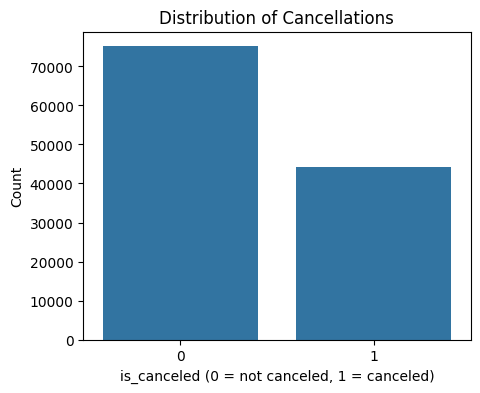

Cancellation rate: 37.04%


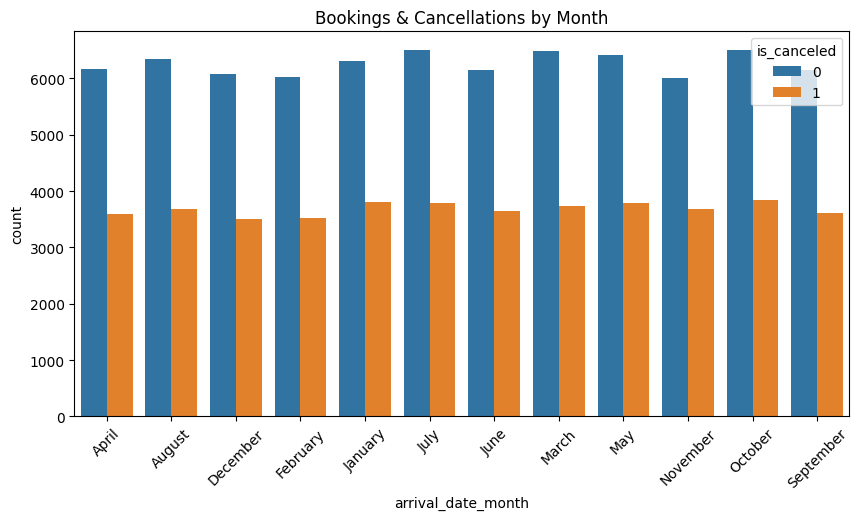

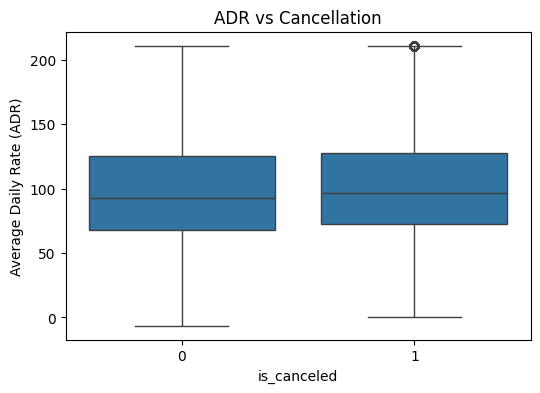

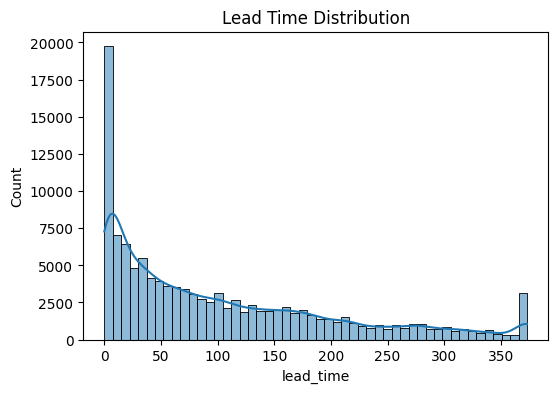

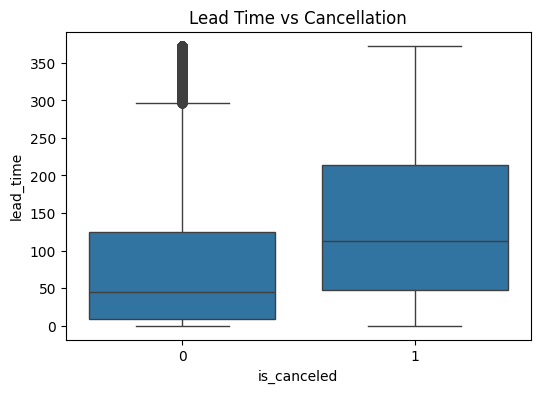

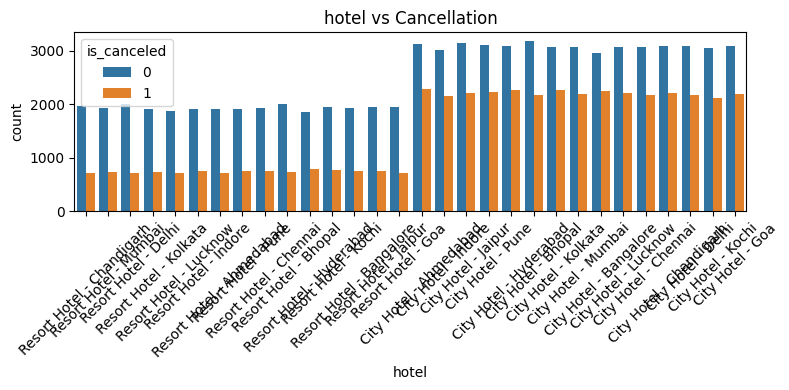

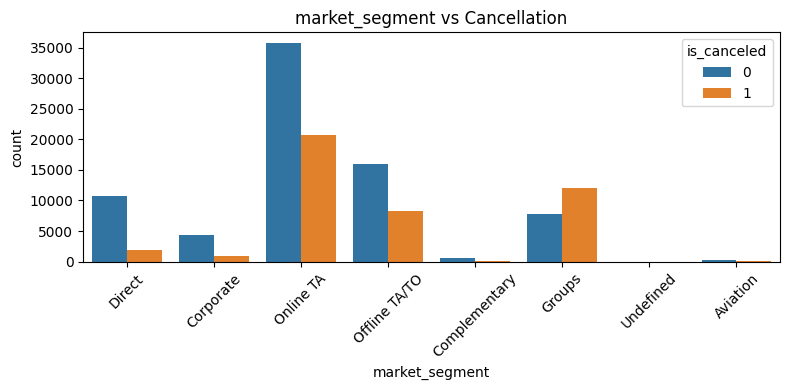

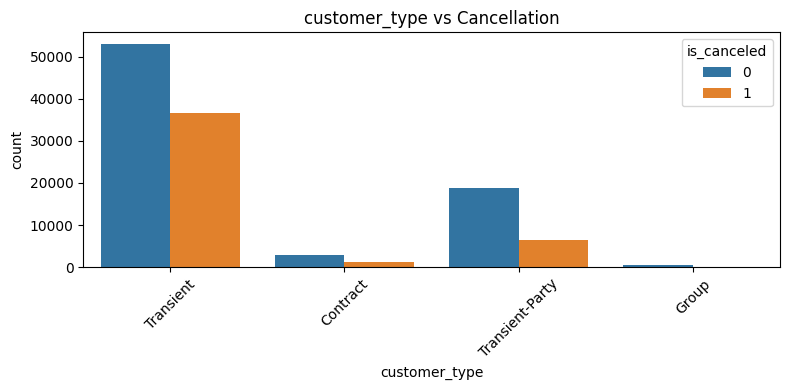

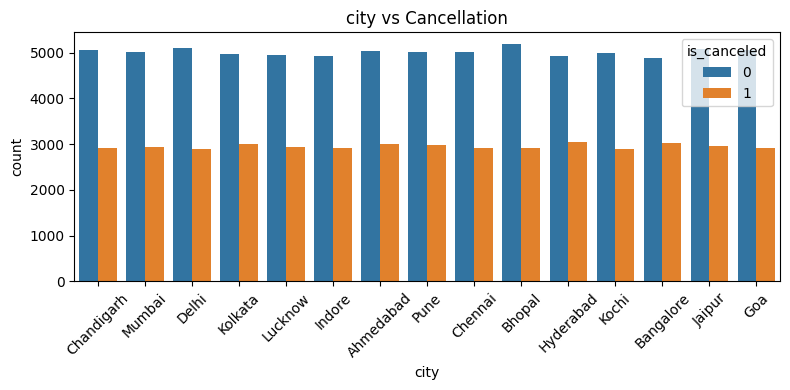

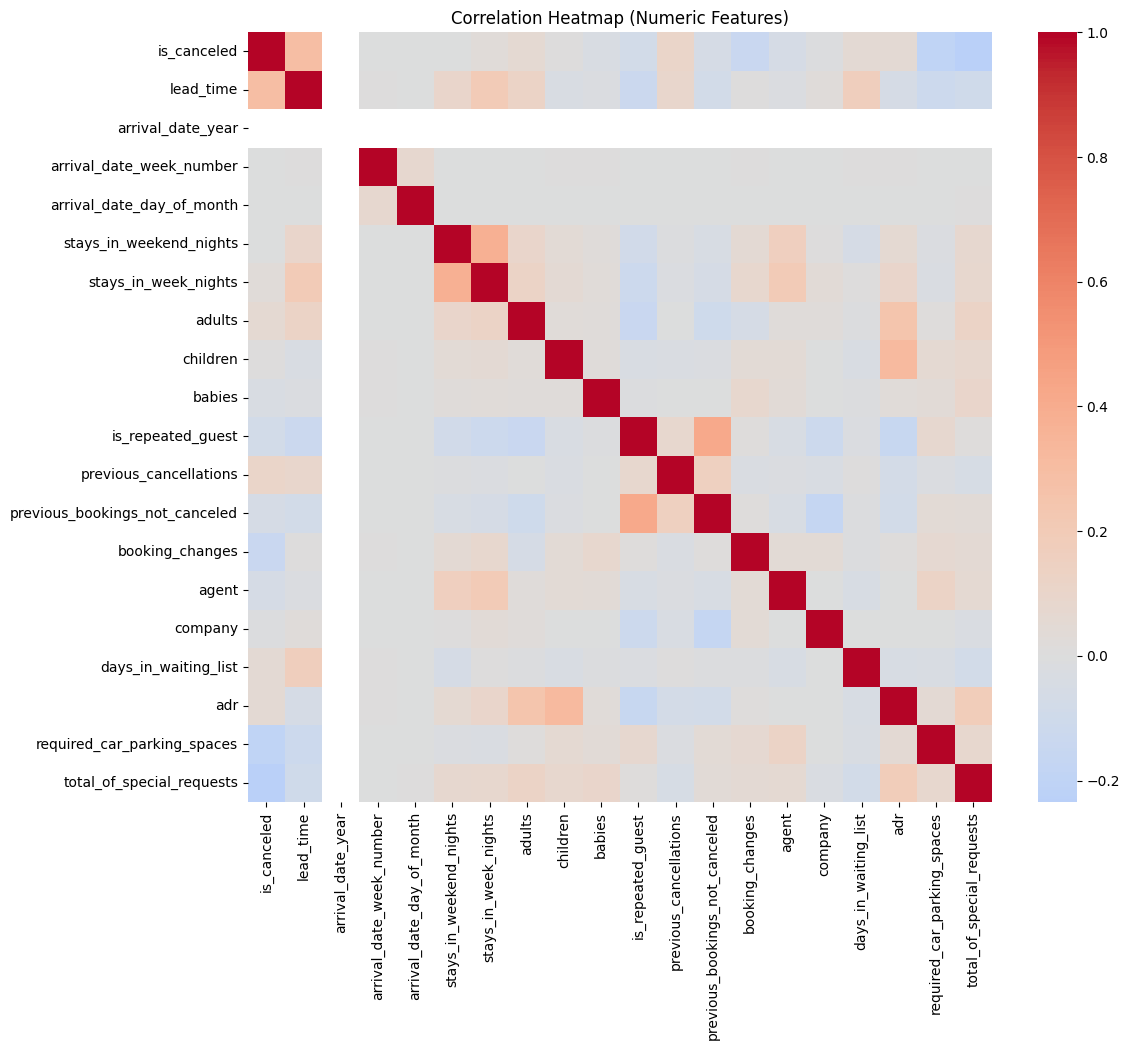

In [ ]:
# 4. Exploratory Data Analysis (EDA)

# 4.1 Target distribution (is_canceled)

if "is_canceled" in df.columns:
    plt.figure(figsize=(5,4))
    sns.countplot(x="is_canceled", data=df)
    plt.title("Distribution of Cancellations")
    plt.xlabel("is_canceled (0 = not canceled, 1 = canceled)")
    plt.ylabel("Count")
    plt.show()

    cancel_rate = df["is_canceled"].mean()
    print(f"Cancellation rate: {cancel_rate:.2%}")
else:
    print("Column 'is_canceled' not found in data.")

# 4.2 Booking trends by arrival month and year

if {"arrival_date_year", "arrival_date_month"}.issubset(df.columns):
    plt.figure(figsize=(10,5))
    sns.countplot(x="arrival_date_month", hue="is_canceled", data=df,
                  order=sorted(df["arrival_date_month"].unique()))
    plt.title("Bookings & Cancellations by Month")
    plt.xticks(rotation=45)
    plt.show()

# 4.3 ADR vs cancellations

if {"adr", "is_canceled"}.issubset(df.columns):
    plt.figure(figsize=(6,4))
    sns.boxplot(x="is_canceled", y="adr", data=df)
    plt.title("ADR vs Cancellation")
    plt.xlabel("is_canceled")
    plt.ylabel("Average Daily Rate (ADR)")
    plt.show()

# 4.4 Lead time analysis

if "lead_time" in df.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df["lead_time"], bins=50, kde=True)
    plt.title("Lead Time Distribution")
    plt.show()

    plt.figure(figsize=(6,4))
    sns.boxplot(x="is_canceled", y="lead_time", data=df)
    plt.title("Lead Time vs Cancellation")
    plt.show()

# 4.5 Categorical plots: hotel, market_segment, customer_type

for cat in ["hotel", "market_segment", "customer_type", "city"]:
    if {cat, "is_canceled"}.issubset(df.columns):
        plt.figure(figsize=(8,4))
        sns.countplot(x=cat, hue="is_canceled", data=df)
        plt.title(f"{cat} vs Cancellation")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

# 4.6 Correlation heatmap (numeric features only)

plt.figure(figsize=(12,10))
num_df = df.select_dtypes(include=["int64", "float64"])
correlation = num_df.corr()
sns.heatmap(correlation, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()




In [ ]:



# 5. Feature Engineering

# 5.1 Create new features

# Total stay nights
if {"stays_in_weekend_nights", "stays_in_week_nights"}.issubset(df.columns):
    df["total_stay_nights"] = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]

# Total guests
for cols in [["adults", "children", "babies"]]:
    if set(cols).issubset(df.columns):
        df["total_guests"] = df["adults"] + df["children"] + df["babies"]

# Is family booking
if {"adults", "children"}.issubset(df.columns):
    df["is_family"] = np.where((df["children"] > 0) | (df["babies"] > 0), 1, 0)

# 5.2 Drop clearly irrelevant or ID-like columns if present

cols_to_drop = []
for col in ["reservation_status", "company", "agent"]:
    if col in df.columns:
        cols_to_drop.append(col)

if cols_to_drop:
    df.drop(columns=cols_to_drop, inplace=True)

print("Dropped columns:", cols_to_drop)

# 5.3 One-hot encode categorical features

target_col = "is_canceled"

if target_col not in df.columns:
    raise ValueError("Target column 'is_canceled' not found in dataframe")

# Drop any remaining datetime columns (e.g., reservation_status_date),
# because scikit-learn scalers and models expect purely numeric inputs.
datetime_cols = df.select_dtypes(include=["datetime64"]).columns.tolist()
if datetime_cols:
    print("Dropping datetime columns before encoding:", datetime_cols)
    df.drop(columns=datetime_cols, inplace=True)

cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Categorical columns to encode:", cat_cols)

# One-hot encode, drop first level to avoid multicollinearity
encoded_df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print("Shape before encoding:", df.shape)
print("Shape after encoding:", encoded_df.shape)


na_before = encoded_df.isna().sum().sum()
print("Total NaNs before final fillna:", na_before)
if na_before > 0:
    encoded_df = encoded_df.fillna(encoded_df.median(numeric_only=True))
    encoded_df = encoded_df.fillna(0)
    print("Total NaNs after final fillna:", encoded_df.isna().sum().sum())

encoded_df.head()



Dropped columns: ['reservation_status', 'company', 'agent']
Dropping datetime columns before encoding: ['reservation_status_date']
Categorical columns to encode: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'city']
Shape before encoding: (119390, 35)
Shape after encoding: (119390, 294)
Total NaNs before final fillna: 0


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,city_Delhi,city_Goa,city_Hyderabad,city_Indore,city_Jaipur,city_Kochi,city_Kolkata,city_Lucknow,city_Mumbai,city_Pune
0,0,342,2024,30,27,0,0,2,0,0,...,False,False,False,False,False,False,False,False,False,False
1,0,373,2024,17,28,0,0,2,0,0,...,False,False,False,False,False,False,False,False,True,False
2,0,7,2024,37,10,0,1,1,0,0,...,True,False,False,False,False,False,False,False,False,False
3,0,13,2024,33,14,0,1,1,0,0,...,False,False,False,False,False,False,True,False,False,False
4,0,14,2024,37,14,0,2,2,0,0,...,False,False,False,False,False,False,False,True,False,False


In [ ]:
# 6. Train / Validation / Test Split (No SMOTE)

X = encoded_df.drop(columns=[target_col])
y = encoded_df[target_col]

# First split: train_val vs test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: train vs validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)  # 0.25 of 0.8 -> 0.2 of total

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

# Check class balance
print("\nClass distribution in training set:")
print(y_train.value_counts(normalize=True))

# For compatibility with the rest of the pipeline, we keep the same variable names
X_train_res, y_train_res = X_train, y_train

# Standardize features (fit on training, apply to val & test)
scaler = StandardScaler()
X_train_res_scaled = scaler.fit_transform(X_train_res)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)



Train shape: (71634, 293)
Validation shape: (23878, 293)
Test shape: (23878, 293)

Class distribution in training set:
is_canceled
0    0.629589
1    0.370411
Name: proportion, dtype: float64


In [ ]:
# 7. Baseline Models (without Genetic Algorithm feature selection)

results_baseline = {}
# 7.1 K-Nearest Neighbors (KNN)

knn_param_grid = {"n_neighbors": [3, 5, 7], "weights": ["uniform", "distance"]}
knn = KNeighborsClassifier()
knn_grid = GridSearchCV(knn, knn_param_grid, cv=3, scoring="f1", n_jobs=-1)
knn_grid.fit(X_train_res_scaled, y_train_res)

best_knn = knn_grid.best_estimator_
print("Best KNN params:", knn_grid.best_params_)

# Evaluate on validation set
val_pred_knn = best_knn.predict(X_val_scaled)

results_baseline["KNN"] = {
    "accuracy": accuracy_score(y_val, val_pred_knn),
    "precision": precision_score(y_val, val_pred_knn),
    "recall": recall_score(y_val, val_pred_knn),
    "f1": f1_score(y_val, val_pred_knn)
}

print("\nKNN Validation Classification Report:\n")
print(classification_report(y_val, val_pred_knn))



Best KNN params: {'n_neighbors': 7, 'weights': 'distance'}

KNN Validation Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.83      0.81     15033
           1       0.68      0.63      0.66      8845

    accuracy                           0.75     23878
   macro avg       0.74      0.73      0.73     23878
weighted avg       0.75      0.75      0.75     23878



In [ ]:

# 7.2 Decision Tree

dt_param_grid = {
    "max_depth": [5, 10, 15],
    "min_samples_split": [2, 5, 10]
}

dt = DecisionTreeClassifier(random_state=42)
dt_grid = GridSearchCV(dt, dt_param_grid, cv=3, scoring="f1", n_jobs=-1)
dt_grid.fit(X_train_res, y_train_res)
best_dt = dt_grid.best_estimator_
print("Best Decision Tree params:", dt_grid.best_params_)

val_pred_dt = best_dt.predict(X_val)

results_baseline["DecisionTree"] = {
    "accuracy": accuracy_score(y_val, val_pred_dt),
    "precision": precision_score(y_val, val_pred_dt),
    "recall": recall_score(y_val, val_pred_dt),
    "f1": f1_score(y_val, val_pred_dt)
}

print("\nDecision Tree Validation Classification Report:\n")
print(classification_report(y_val, val_pred_dt))



Best Decision Tree params: {'max_depth': 15, 'min_samples_split': 5}

Decision Tree Validation Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.89      0.87     15032
           1       0.80      0.75      0.77      8843

    accuracy                           0.84     23875
   macro avg       0.83      0.82      0.82     23875
weighted avg       0.84      0.84      0.84     23875



In [ ]:

# 7.3 Neural Network (MLPClassifier)

mlp_param_grid = {
    "hidden_layer_sizes": [(64,), (64, 32)],
    "alpha": [0.0001, 0.001]
}

mlp = MLPClassifier(max_iter=200, random_state=42)
mlp_grid = GridSearchCV(mlp, mlp_param_grid, cv=3, scoring="f1", n_jobs=-1)
mlp_grid.fit(X_train_res_scaled, y_train_res)

best_mlp = mlp_grid.best_estimator_
print("Best MLP params:", mlp_grid.best_params_)

val_pred_mlp = best_mlp.predict(X_val_scaled)

results_baseline["MLP"] = {
    "accuracy": accuracy_score(y_val, val_pred_mlp),
    "precision": precision_score(y_val, val_pred_mlp),
    "recall": recall_score(y_val, val_pred_mlp),
    "f1": f1_score(y_val, val_pred_mlp)
}

print("\nMLP Validation Classification Report:\n")
print(classification_report(y_val, val_pred_mlp))

print("\nBaseline model comparison (validation):")
print(pd.DataFrame(results_baseline).T)



Best MLP params: {'alpha': 0.0001, 'hidden_layer_sizes': (64,)}

MLP Validation Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.87      0.86     15032
           1       0.78      0.74      0.76      8843

    accuracy                           0.82     23875
   macro avg       0.81      0.81      0.81     23875
weighted avg       0.82      0.82      0.82     23875


Baseline model comparison (validation):
              accuracy  precision    recall        f1
KNN           0.756272   0.684841  0.633495  0.658168
DecisionTree  0.838660   0.802228  0.749067  0.774737
MLP           0.824670   0.776314  0.739794  0.757614


In [ ]:
# 8. Genetic Algorithm (GA) for Feature Selection


num_features = X_train_res.shape[1]
feature_names = X_train_res.columns.tolist()

# GA hyperparameters
POP_SIZE = 20
N_GENERATIONS = 10
MUTATION_RATE = 0.1
TOURNAMENT_SIZE = 3

random.seed(42)

# ---- 8.1 Helper functions ----

def create_individual():
    """Create a random binary mask of features (at least 1 feature)."""
    while True:
        mask = np.random.randint(0, 2, size=num_features)
        if mask.sum() > 0:
            return mask


def evaluate_individual(mask):
    """Return F1-score on validation set for selected features."""
    selected_idx = np.where(mask == 1)[0]
    if len(selected_idx) == 0:
        return 0.0

    X_tr = X_train_res.iloc[:, selected_idx]
    X_v = X_val.iloc[:, selected_idx]

    # simple Decision Tree for speed
    clf = DecisionTreeClassifier(max_depth=10, random_state=42)
    clf.fit(X_tr, y_train_res)
    preds = clf.predict(X_v)
    return f1_score(y_val, preds)


def tournament_selection(population, fitnesses):
    """Select an individual via tournament selection."""
    indices = np.random.choice(len(population), size=TOURNAMENT_SIZE, replace=False)
    best_idx = indices[0]
    best_fit = fitnesses[indices[0]]
    for idx in indices[1:]:
        if fitnesses[idx] > best_fit:
            best_fit = fitnesses[idx]
            best_idx = idx
    return population[best_idx].copy()


def crossover(parent1, parent2):
    """Single-point crossover."""
    if len(parent1) != len(parent2):
        raise ValueError("Parents must be same length")
    point = np.random.randint(1, len(parent1))
    child1 = np.concatenate([parent1[:point], parent2[point:]])
    child2 = np.concatenate([parent2[:point], parent1[point:]])
    return child1, child2


def mutate(mask):
    """Flip bits with probability MUTATION_RATE."""
    for i in range(len(mask)):
        if np.random.rand() < MUTATION_RATE:
            mask[i] = 1 - mask[i]
    # Ensure at least one feature
    if mask.sum() == 0:
        idx = np.random.randint(0, len(mask))
        mask[idx] = 1
    return mask

# ---- 8.2 GA main loop ----

# Initialize population
population = [create_individual() for _ in range(POP_SIZE)]

best_mask = None
best_f1 = -1

for gen in range(N_GENERATIONS):
    fitnesses = np.array([evaluate_individual(ind) for ind in population])

    gen_best_idx = np.argmax(fitnesses)
    gen_best_f1 = fitnesses[gen_best_idx]

    if gen_best_f1 > best_f1:
        best_f1 = gen_best_f1
        best_mask = population[gen_best_idx].copy()

    print(f"Generation {gen+1}/{N_GENERATIONS} - Best F1: {gen_best_f1:.4f}")

    # Create new population
    new_population = [population[gen_best_idx].copy()]

    while len(new_population) < POP_SIZE:
        parent1 = tournament_selection(population, fitnesses)
        parent2 = tournament_selection(population, fitnesses)
        child1, child2 = crossover(parent1, parent2)
        child1 = mutate(child1)
        child2 = mutate(child2)
        new_population.extend([child1, child2])

    population = new_population[:POP_SIZE]

print("\nBest GA validation F1:", best_f1)

selected_indices = np.where(best_mask == 1)[0]
selected_features = [feature_names[i] for i in selected_indices]

print("Number of selected features:", len(selected_features))
print("Selected features:")
print(selected_features)



Generation 1/10 - Best F1: 0.7654
Generation 2/10 - Best F1: 0.7672
Generation 3/10 - Best F1: 0.7684
Generation 4/10 - Best F1: 0.7684
Generation 5/10 - Best F1: 0.7718
Generation 6/10 - Best F1: 0.7721
Generation 7/10 - Best F1: 0.7727
Generation 8/10 - Best F1: 0.7742
Generation 9/10 - Best F1: 0.7770
Generation 10/10 - Best F1: 0.7770

Best GA validation F1: 0.7769767837883862
Number of selected features: 156
Selected features:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'children', 'babies', 'previous_cancellations', 'booking_changes', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status_month', 'reservation_status_day', 'total_guests', 'hotel_City Hotel - Bhopal', 'hotel_City Hotel - Chandigarh', 'hotel_City Hotel - Chennai', 'hotel_City Hotel - Goa', 'hotel_City Hotel - Jaipur', 'hotel_City Hotel - Kolkata', 'hotel_City Hotel - Lucknow', 'hotel_City Hotel - Pune', 'hotel_Resort 

In [ ]:
# 9. Models Using GA-Selected Features

# Subset data using GA-selected features
X_train_ga = X_train_res[selected_features]
X_val_ga = X_val[selected_features]
X_test_ga = X_test[selected_features]

# Re-fit scaler on GA-selected features for models that need scaling
scaler_ga = StandardScaler()
X_train_ga_scaled = scaler_ga.fit_transform(X_train_ga)
X_val_ga_scaled = scaler_ga.transform(X_val_ga)
X_test_ga_scaled = scaler_ga.transform(X_test_ga)

results_ga = {}

# 9.1 KNN with GA features

knn_ga = KNeighborsClassifier(**knn_grid.best_params_)
knn_ga.fit(X_train_ga_scaled, y_train_res)
val_pred_knn_ga = knn_ga.predict(X_val_ga_scaled)

results_ga["KNN_GA"] = {
    "accuracy": accuracy_score(y_val, val_pred_knn_ga),
    "precision": precision_score(y_val, val_pred_knn_ga),
    "recall": recall_score(y_val, val_pred_knn_ga),
    "f1": f1_score(y_val, val_pred_knn_ga)
}

# 9.2 Decision Tree with GA features

dt_ga = DecisionTreeClassifier(**dt_grid.best_params_, random_state=42)
dt_ga.fit(X_train_ga, y_train_res)
val_pred_dt_ga = dt_ga.predict(X_val_ga)

results_ga["DecisionTree_GA"] = {
    "accuracy": accuracy_score(y_val, val_pred_dt_ga),
    "precision": precision_score(y_val, val_pred_dt_ga),
    "recall": recall_score(y_val, val_pred_dt_ga),
    "f1": f1_score(y_val, val_pred_dt_ga)
}

# 9.3 MLP with GA features

mlp_ga = MLPClassifier(**mlp_grid.best_params_, max_iter=200, random_state=42)
mlp_ga.fit(X_train_ga_scaled, y_train_res)
val_pred_mlp_ga = mlp_ga.predict(X_val_ga_scaled)

results_ga["MLP_GA"] = {
    "accuracy": accuracy_score(y_val, val_pred_mlp_ga),
    "precision": precision_score(y_val, val_pred_mlp_ga),
    "recall": recall_score(y_val, val_pred_mlp_ga),
    "f1": f1_score(y_val, val_pred_mlp_ga)
}

print("GA-based model comparison (validation):")
print(pd.DataFrame(results_ga).T)



GA-based model comparison (validation):
                 accuracy  precision    recall        f1
KNN_GA           0.763560   0.695143  0.644125  0.668662
DecisionTree_GA  0.834848   0.784421  0.764107  0.774131
MLP_GA           0.829738   0.777533  0.756870  0.767062


Validation comparison (all models):
                 accuracy  precision    recall        f1
KNN              0.756272   0.684841  0.633495  0.658168
DecisionTree     0.838660   0.802228  0.749067  0.774737
MLP              0.824670   0.776314  0.739794  0.757614
KNN_GA           0.763560   0.695143  0.644125  0.668662
DecisionTree_GA  0.834848   0.784421  0.764107  0.774131
MLP_GA           0.829738   0.777533  0.756870  0.767062

Best model on validation set: DecisionTree

Test Set Performance of Best Model:
Accuracy: 0.8372
Precision: 0.8023
Recall: 0.7436
F1 Score: 0.7718

Confusion Matrix:
[[13413  1620]
 [ 2267  6575]]


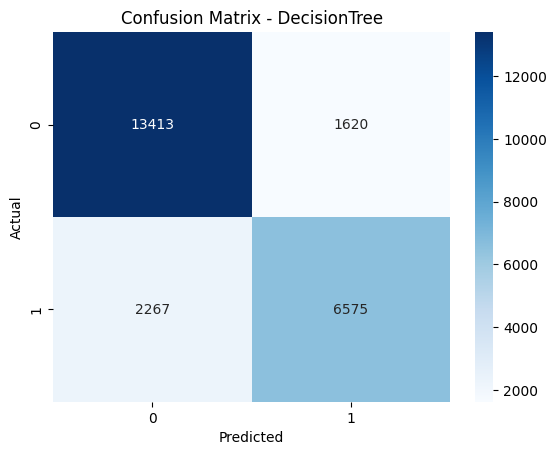

In [ ]:
# 10. Final Evaluation on Test Set (Best Model Selection)

# Combining baseline and GA results on validation set
comparison_val = pd.concat([
    pd.DataFrame(results_baseline).T,
    pd.DataFrame(results_ga).T
])

print("Validation comparison (all models):")
print(comparison_val)

# Choosing best model based on F1-score
best_model_name = comparison_val["f1"].idxmax()
print("\nBest model on validation set:", best_model_name)

# Building the corresponding trained model for test evaluation

if best_model_name == "KNN":
    final_model = best_knn
    X_train_final = X_train_res_scaled
    X_test_final = X_test_scaled
elif best_model_name == "DecisionTree":
    final_model = best_dt
    X_train_final = X_train_res
    X_test_final = X_test
elif best_model_name == "MLP":
    final_model = best_mlp
    X_train_final = X_train_res_scaled
    X_test_final = X_test_scaled
elif best_model_name == "KNN_GA":
    final_model = knn_ga
    X_train_final = X_train_ga_scaled
    X_test_final = X_test_ga_scaled
elif best_model_name == "DecisionTree_GA":
    final_model = dt_ga
    X_train_final = X_train_ga
    X_test_final = X_test_ga
elif best_model_name == "MLP_GA":
    final_model = mlp_ga
    X_train_final = X_train_ga_scaled
    X_test_final = X_test_ga_scaled
else:
    raise ValueError("Unknown best model name")

# Refit on full training (train_resampled) data for fairness
final_model.fit(X_train_final, y_train_res)

y_test_pred = final_model.predict(X_test_final)

acc = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred)
rec = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
cm = confusion_matrix(y_test, y_test_pred)

print("\nTest Set Performance of Best Model:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")

print("\nConfusion Matrix:")
print(cm)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
